In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\_aromatic_2025_637_CClHNS.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
626,"2,4-Diamino-5-[p-chlorophenylazo]-6-mercaptopy...",C10H9ClN6S,280,6979-70-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Nc1nc(N)c(N=Nc2ccc(Cl)cc2)c(S)n1,CClHNS
1307,"Carbothioamide, 1-hydrazine-2-[1-(2,6-dichloro...",C8H7Cl2N3S,247,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NC(=S)N/N=C/c1c(Cl)cccc1Cl,CClHNS
1308,"1-Hydrazinethiocarbamide, 2-(3,5-dichlorobenzy...",C8H7Cl2N3S,247,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NC(=S)NN=Cc1cc(Cl)cc(Cl)c1,CClHNS
1310,"1-(2,4-Dichlorobenzylidene)-3-thiosemicarbazide",C8H7Cl2N3S,247,6957-92-2,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NC(=S)N/N=C/c1ccc(Cl)cc1Cl,CClHNS
1319,"Benzaldehyde, o-chloro-, 3-thiosemicarbazone",C8H8ClN3S,213,5706-78-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,NC(=S)N/N=C/c1ccccc1Cl,CClHNS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180582,N-[4-(4-Chlorophenyl)isothiazol-5-yl)-1-methyl...,C15H16ClN3S,305,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CN1CCCCC1=Nc2sncc2c3ccc(Cl)cc3,CClHNS
180645,"1,3,5-Triazine, 2-(butylthio)-4,6-bis(trichlor...",C9H9Cl6N3S,401,24504-18-5,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCCCSc1nc(nc(n1)C(Cl)(Cl)Cl)C(Cl)(Cl)Cl,CClHNS
180679,"1-[1-(2,2-Dichlorovinylimino)-2,2-dimethylprop...",C15H19Cl2N3S,343,92277-61-7,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Cc1ccc(NC(=S)NC(=NC=C(Cl)Cl)C(C)(C)C)cc1,CClHNS
181314,1-Allyl-4-dichloromethyl-2-(p-tolyl)-6(1H)-thi...,C14H13Cl2N3S,325,163433-85-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,Cc1ccc(cc1)C2=NC(=NC(=S)N2CC=C)C(Cl)Cl,CClHNS


In [4]:
import deepchem as dc
import selfies as sf
import pandas as pd

# Assuming ms is your DataFrame
X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(637), np.int64(600)), y.shape: (np.int64(637),), w.shape: (np.int64(637),), ids: [0 1 2 ... 634 635 636], task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/-Ring1]': 4,
 '[/C]': 5,
 '[/N]': 6,
 '[=Branch1]': 7,
 '[=Branch2]': 8,
 '[=C]': 9,
 '[=N]': 10,
 '[=Ring1]': 11,
 '[=Ring2]': 12,
 '[=S]': 13,
 '[Branch1]': 14,
 '[Branch2]': 15,
 '[C@H1]': 16,
 '[C]': 17,
 '[Cl]': 18,
 '[NH1]': 19,
 '[N]': 20,
 '[O]': 21,
 '[P]': 22,
 '[Ring1]': 23,
 '[Ring2]': 24,
 '[S]': 25,
 '[\\C]': 26,
 '[\\N]': 27,
 '[nop]': 28}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 548
📦 Validation set size: 0
📦 Test set size: 89


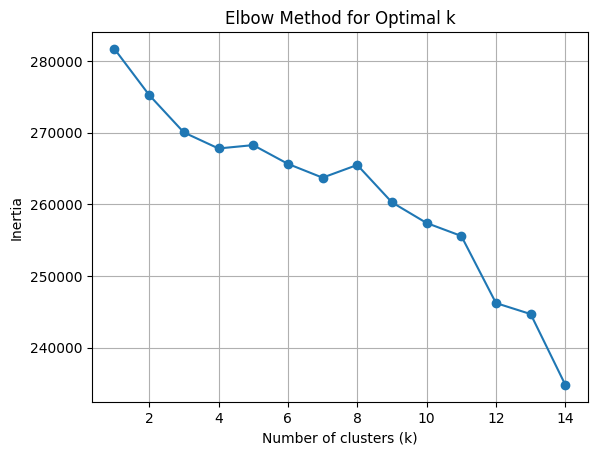

🔍 Elbow point detected at k = 3


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [12]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=3,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

In [13]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(3):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (25, 600)
Cluster 1 shape: (445, 600)
Cluster 2 shape: (78, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

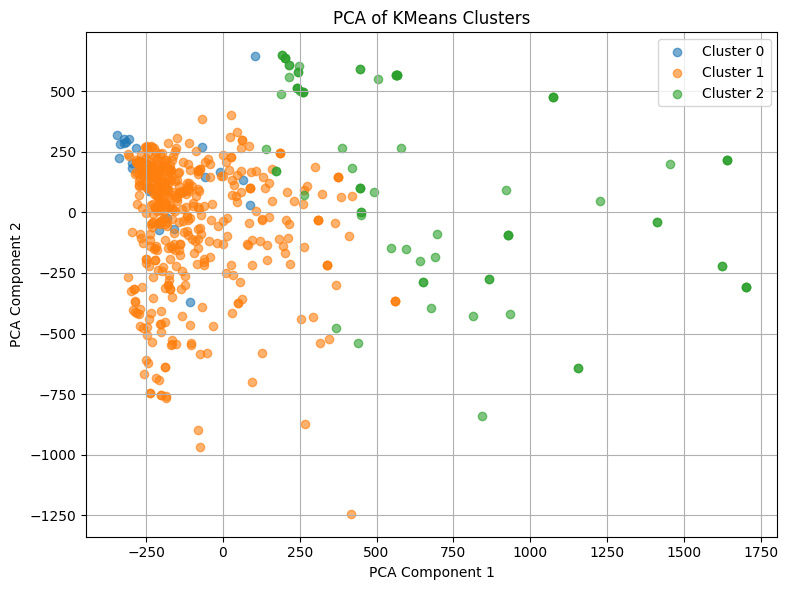

In [14]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=3)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [15]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [16]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_in

Cluster 0: size = 3, shape = (3, 600)
Cluster 1: size = 74, shape = (74, 600)
Cluster 2: size = 12, shape = (12, 600)


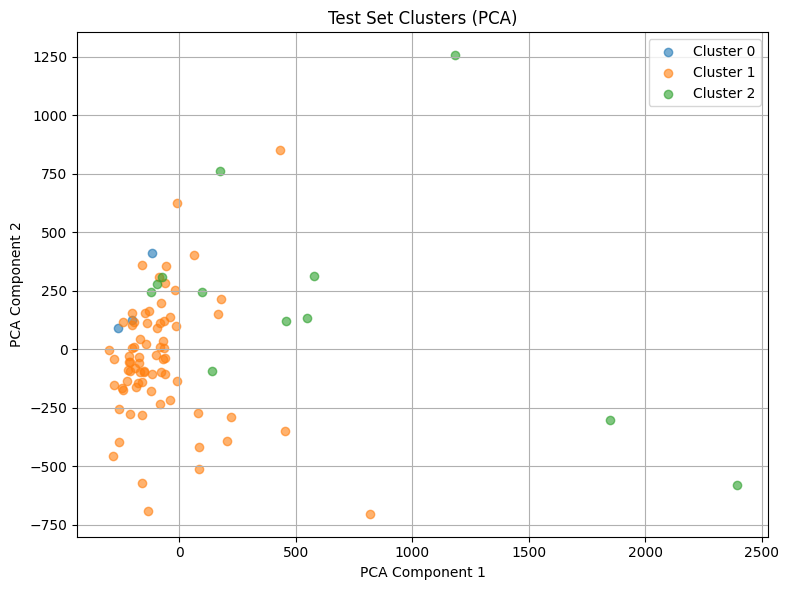

In [17]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(3):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.608149
Epoch 2/100 - Loss: 0.089657
Epoch 3/100 - Loss: 0.030003
Epoch 4/100 - Loss: 0.026453
Epoch 5/100 - Loss: 0.024198
Epoch 6/100 - Loss: 0.020373
Epoch 7/100 - Loss: 0.016989
Epoch 8/100 - Loss: 0.013989
Epoch 9/100 - Loss: 0.012923
Epoch 10/100 - Loss: 0.011702
Epoch 11/100 - Loss: 0.010817
Epoch 12/100 - Loss: 0.009834
Epoch 13/100 - Loss: 0.008973
Epoch 14/100 - Loss: 0.008584
Epoch 15/100 - Loss: 0.008026
Epoch 16/100 - Loss: 0.007497
Epoch 17/100 - Loss: 0.006884
Epoch 18/100 - Loss: 0.006435
Epoch 19/100 - Loss: 0.005746
Epoch 20/100 - Loss: 0.005474
Epoch 21/100 - Loss: 0.005052
Epoch 22/100 - Loss: 0.004765
Epoch 23/100 - Loss: 0.004454
Epoch 24/100 - Loss: 0.003927
Epoch 25/100 - Loss: 0.003730
Epoch 26/100 - Loss: 0.003490
Epoch 27/100 - Loss: 0.003419
Epoch 28/100 - Loss: 0.003093
Epoch 29/100 - Loss: 0.002758
Epoch 30/100 - Loss: 0.002701
Epoch 31/100 - Loss: 0.002389
Epoch 32/100 - Loss: 0.002273
Epoch 33/100 - Loss: 0.002147
Epoch 34/100 - Loss

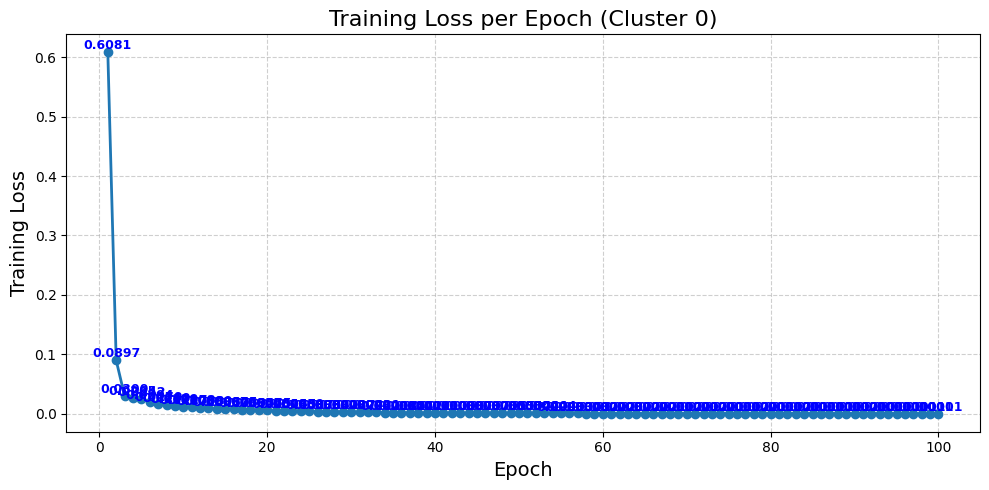

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\models_\model0000


In [18]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [19]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [20]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (3, 1827, 2)
Example prediction: [[1.0000000e+00 2.5349895e-18]
 [1.0000000e+00 2.1021537e-14]
 [1.0000000e+00 2.6858210e-17]
 ...
 [1.0000000e+00 7.3945430e-18]
 [1.0000000e+00 1.7442080e-16]
 [1.7984250e-13 1.0000000e+00]]


In [21]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [22]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [23]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: NCC=C(S)CSC1C[NH1]C=NC=CC=C1 | True: ClC1=CC=C(CCNC2=CC=C3NC(=S)NC(=S)C3=N2)C=C1Cl | Tanimoto: 0.109
[1] Pred: ClC=CC=CPS1CC=CC(Cl)(Cl)C1N=N | True: ClC1=CC=CC(Cl)=C1CSC#N | Tanimoto: 0.080
[2] Pred: ClC1=CC=C(CSC=2[NH1]C3=NC=CC=C3N=2)C(Cl)=C1 | True: ClC1=CC=C(CSC=2[NH1]C3=NC=CC=C3N=2)C=C1Cl | Tanimoto: 0.855

📊 Evaluation Summary:
✅ Exact SMILES match: 0/3 (0.0%)
Tanimoto >= 1.0: 0
Tanimoto >= 0.9: 0
Tanimoto >= 0.6: 1
Avg Tanimoto: 0.348


Epoch 1/100 - Loss: 0.625443
Epoch 2/100 - Loss: 0.073349
Epoch 3/100 - Loss: 0.058876
Epoch 4/100 - Loss: 0.054382
Epoch 5/100 - Loss: 0.051530
Epoch 6/100 - Loss: 0.048969
Epoch 7/100 - Loss: 0.046535
Epoch 8/100 - Loss: 0.044205
Epoch 9/100 - Loss: 0.042019
Epoch 10/100 - Loss: 0.039491
Epoch 11/100 - Loss: 0.037293
Epoch 12/100 - Loss: 0.035359
Epoch 13/100 - Loss: 0.033348
Epoch 14/100 - Loss: 0.030975
Epoch 15/100 - Loss: 0.029208
Epoch 16/100 - Loss: 0.027017
Epoch 17/100 - Loss: 0.025132
Epoch 18/100 - Loss: 0.023565
Epoch 19/100 - Loss: 0.021641
Epoch 20/100 - Loss: 0.019799
Epoch 21/100 - Loss: 0.018389
Epoch 22/100 - Loss: 0.017319
Epoch 23/100 - Loss: 0.015562
Epoch 24/100 - Loss: 0.014458
Epoch 25/100 - Loss: 0.013148
Epoch 26/100 - Loss: 0.012137
Epoch 27/100 - Loss: 0.011340
Epoch 28/100 - Loss: 0.010551
Epoch 29/100 - Loss: 0.009783
Epoch 30/100 - Loss: 0.009009
Epoch 31/100 - Loss: 0.008764
Epoch 32/100 - Loss: 0.007702
Epoch 33/100 - Loss: 0.007459
Epoch 34/100 - Loss

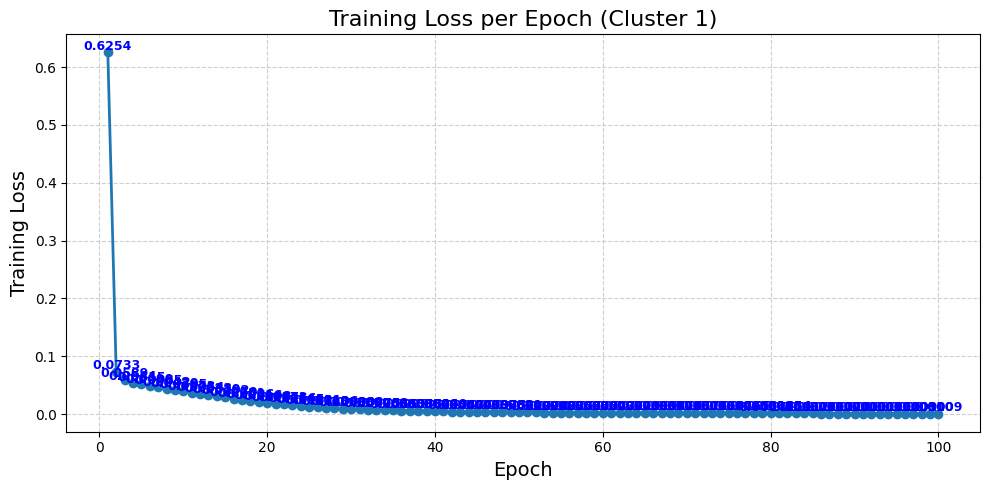

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\models_\model1111


In [24]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [25]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (74, 1827, 2)
Example prediction: [[1.0000000e+00 7.2914057e-11]
 [1.0000000e+00 9.2418061e-12]
 [1.0000000e+00 2.8195824e-11]
 ...
 [1.0000000e+00 1.8238320e-13]
 [1.0000000e+00 4.5475429e-12]
 [1.4531070e-13 1.0000000e+00]]
[0] Pred: ClCC=CSCC=CCC | True: SCC1=CSC(=N1)C2=CC=C(Cl)C=C2 | Tanimoto: 0.029
[1] Pred: C1C=CC=CC1=CCCC#C | True: CC1CN(C)C(S1)=NC2=CC=C(Cl)C=C2 | Tanimoto: 0.037
[2] Pred: ClC=CC=CC=CNCC | True: ClC1=CC=C(N=C1)N=C2SSN=C2Cl | Tanimoto: 0.032
[3] Pred: CC1=NN=C2SCC(=NN12)C3=CC=C(Cl)C(Cl)=C3 | True: CC1=NN=C2SCC(=NN12)C3=CC=C(Cl)C=C3Cl | Tanimoto: 0.854
[4] Pred: NC=1N(N=C(C2=CC=C(Cl)C=C2)C=1SC#N)C3=CC=CC=C3 | True: NC=1N(N=C(C2=CC=C(Cl)C=C2)C=1SC#N)C3=CC=CC=C3 | Tanimoto: 1.000
[5] Pred: C\C(=N/NC(=S)NC1=CC(Cl)=CC(Cl)=C1)C2=CC=CC=N2 | True: C\C(=N/NC(=S)NC1=CC(Cl)=CC(Cl)=C1)C2=CC=CC=N2 | Tanimoto: 1.000
[6] Pred: CCN(CC)CCCC(C)NC1=NSC2=CC=C(Cl)C=C12 | True: CCN(CC)CCCC(C)NC1=NSC2=CC=C(Cl)C=C12 | Tanimoto: 1.000
[7] Pred: CN(C)CCCNC=NSC=CCl | Tr

Epoch 1/100 - Loss: 2.086723
Epoch 2/100 - Loss: 0.284393
Epoch 3/100 - Loss: 0.099179
Epoch 4/100 - Loss: 0.083024
Epoch 5/100 - Loss: 0.075572
Epoch 6/100 - Loss: 0.062840
Epoch 7/100 - Loss: 0.052856
Epoch 8/100 - Loss: 0.045750
Epoch 9/100 - Loss: 0.041820
Epoch 10/100 - Loss: 0.039548
Epoch 11/100 - Loss: 0.037567
Epoch 12/100 - Loss: 0.035290
Epoch 13/100 - Loss: 0.033472
Epoch 14/100 - Loss: 0.031584
Epoch 15/100 - Loss: 0.029936
Epoch 16/100 - Loss: 0.027721
Epoch 17/100 - Loss: 0.026464
Epoch 18/100 - Loss: 0.024754
Epoch 19/100 - Loss: 0.023141
Epoch 20/100 - Loss: 0.021684
Epoch 21/100 - Loss: 0.020154
Epoch 22/100 - Loss: 0.018706
Epoch 23/100 - Loss: 0.016887
Epoch 24/100 - Loss: 0.016069
Epoch 25/100 - Loss: 0.014688
Epoch 26/100 - Loss: 0.013411
Epoch 27/100 - Loss: 0.012018
Epoch 28/100 - Loss: 0.011464
Epoch 29/100 - Loss: 0.009931
Epoch 30/100 - Loss: 0.009446
Epoch 31/100 - Loss: 0.008159
Epoch 32/100 - Loss: 0.007570
Epoch 33/100 - Loss: 0.006852
Epoch 34/100 - Loss

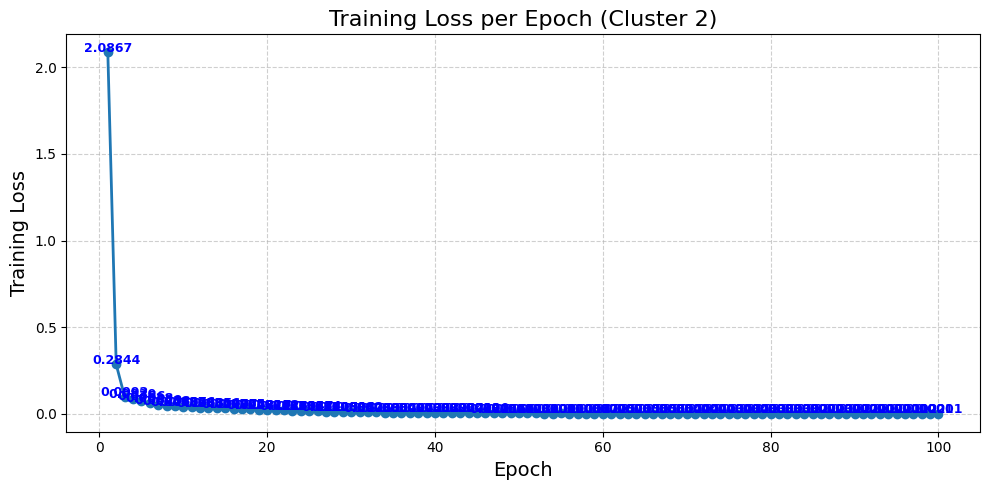

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\models_\model2222


In [26]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [27]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_637_CClHNS\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (12, 1827, 2)
Example prediction: [[1.0000000e+00 7.5139539e-15]
 [1.0000000e+00 1.0470884e-14]
 [1.0000000e+00 4.4594385e-13]
 ...
 [1.0000000e+00 9.2879848e-15]
 [1.0000000e+00 5.0745668e-22]
 [4.5589166e-17 1.0000000e+00]]
[0] Pred: ClC1=CC=CC(=C1)C2=NN=C(SCC3=CC=C(C=C3Cl)C#N)N2CC=C | True: ClC1=CC=CC(=C1)C2=NN=C(SCC3=CC=C(C=C3Cl)C#N)N2CC=C | Tanimoto: 1.000
[1] Pred: CC(C)CSC1=NC(=NC(=N1)C(Cl)(Cl)Cl)C(Cl)(Cl)Cl | True: CC(C)CSC1=NC(=NC(=N1)C(Cl)(Cl)Cl)C(Cl)(Cl)Cl | Tanimoto: 1.000
[2] Pred: ClC1=CC=CC=C1N2CN(CNC2=S)C3CCCC3 | True: ClC1=CC=CC=C1N2CN(CNC2=S)C3CCCC3 | Tanimoto: 1.000
[3] Pred: CCCCCNC(C)(C)C(SS)C1=CC=C(Cl)C=C1 | True: CC(C)CCNC(C)(C)C(SS)C1=CC=C(Cl)C=C1 | Tanimoto: 0.978
[4] Pred: CCC=CC=CNCC(C)CCl | True: CC1=C(SC2=NC(N)=NC(N)=C12)C3=CC=C(Cl)C(Cl)=C3 | Tanimoto: 0.049
[5] Pred: NC(=S)NN=CC1=CC(Cl)=CC(Cl)=C1 | True: NC(=S)NN=CC1=CC(Cl)=CC(Cl)=C1 | Tanimoto: 1.000
[6] Pred: NC(=S)N/N=C/C1=CC=C(Cl)C=C1Cl | True: NC(=S)N/N=C/C1=CC=C(Cl)C=C1Cl | Tanimo